# L15b Lab: Spiking Hebbian Memory on MNIST
In this lab, we integrate the rate-domain Hebbian Memory module of the L15a example onto Leaky Integrate-and-Fire (LIF) neurons as shown in [Limbacher, Özdenizci, and Legenstein (2022)](https://arxiv.org/abs/2205.11276). The key-layer and value-layer are now populations of LIF neurons; the association matrix $\mathbf{W}^{\text{assoc}}$ is updated by an outer product on the _low-pass-filtered spike traces_ $\kappa^{\text{key}}, \kappa^{\text{value}}$ rather than on instantaneous activations. We never train any encoder; the network's learning happens through the local Hebbian write rule, exactly as it would on neuromorphic hardware.

__Problem statement.__ We will store $N$ (key, value) pairs in a single spiking H-Mem network. Each key is a random sparse spike train; each value is the rate-coded spike representation of an MNIST handwritten-digit image (one input neuron per pixel). After all $N$ pairs have been written, we re-present each query key alone and decode the value-layer's spike train back into an image. Because the value-layer has 784 LIF neurons (one per pixel), decoding is just averaging spikes per neuron and reshaping to a $28\times 28$ matrix.

> __Learning Objectives.__ After working through this notebook you should be able to:
>
> * __Simulate a LIF neuron with synaptic-trace dynamics:__ Drive an LIF layer with a Poisson-encoded input current, recover the membrane-potential trajectory and the spike train, and overlay the corresponding spike trace $\kappa(t)$ that the Hebbian rule will consume.
> * __Run the spike-trace Hebbian write and recall rules on synthetic key-value pairs:__ Build a spiking H-Mem network with key- and value-layers of LIF neurons, present $N$ random (key-spike-train, value-spike-train) pairs, update the association matrix via the trace-based outer-product rule from Eq. 6 of Limbacher et al. (2022), and probe the network with one of the stored keys to recover the corresponding value.
> * __Recall MNIST images one-shot from a spiking associative memory:__ Replace the random value-spike-trains with rate-coded MNIST digit images, store $N$ (key, image) pairs, query with one key, decode the recalled value-layer spike train back into a $28\times 28$ image by per-neuron spike averaging, and compare reconstruction quality to the cross-recall baseline.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, which sets paths, loads external packages, and pulls in the spiking-H-Mem source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines the `MySpikingHMemNetwork` struct.
* [`src/Factory.jl`](src/Factory.jl) defines the `build(MySpikingHMemNetwork; ...)` constructor with defaults from Table 2 of [Limbacher et al. (2022)](https://arxiv.org/abs/2205.11276).
* [`src/Compute.jl`](src/Compute.jl) defines `H`, `poisson_encode`, `simulate_lif_layer`, `spike_trace`, `write_phase!`, `recall_phase`, `image_to_rate_input`, and `decode_value_spikes`.
* [`src/Files.jl`](src/Files.jl) defines `list_mnist_files` and `load_mnist_image` for the MNIST images shipped under `data/mnist/`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-15/L15b`


### Constants
We fix the LIF dynamical hyperparameters, the trace time constant, the Hebbian gains, and the network sizes up front. Defaults follow Table 2 of [Limbacher, Özdenizci, and Legenstein (2022)](https://arxiv.org/abs/2205.11276): firing threshold $\vartheta = 0.1$, refractory period $\Delta_{\text{abs}} = 3$ ms, membrane and trace time constants $\tau_{m} = \tau_{\text{trace}} = 20$ ms, soft weight upper bound $w^{\max} = 1.0$, Hebbian gains $\gamma_{+} = \gamma_{-} = 0.3$. The recall coupling `c_assoc` is bumped from the paper's $0.2$ to $1.0$ to compensate for the smaller populations used here.

In [2]:
Δt          = 1.0          # simulation time step (ms)
ϑ           = 0.1          # firing threshold (Limbacher 2022, Tab. 2)
τ_m         = 20.0         # membrane time constant (ms)
τ_trace     = 20.0         # synaptic-trace time constant (ms)
Δ_abs       = 3            # absolute refractory period in time steps
γ_plus      = 0.3          # Hebbian "fire together, wire together" gain
γ_minus     = 0.3          # Oja-style forgetting gain
w_max       = 1.0          # soft upper bound on entries of W^assoc
c_assoc     = 1.0          # recall current scale (paper: 0.2 with ell=100; we use 1.0 at smaller ell)
T_PER_PAIR  = 200          # ms per (key, value) presentation
MAX_RATE    = 0.6          # max per-time-step Poisson firing probability
ELL_TASK2   = 64           # number of LIF neurons in each of the key/value layers (Task 2)
N_TASK2     = 4            # number of (key, value) spike-pair stores (Task 2)
ELL_KEY     = 64           # key-layer size (Task 3)
MNIST_ROWS  = 28           # MNIST image rows
MNIST_COLS  = 28           # MNIST image cols
ELL_VALUE   = MNIST_ROWS * MNIST_COLS  # one value-neuron per pixel (Task 3)
DIGITS_TO_STORE = [3, 5, 8];  # MNIST digit classes to memorize (Task 3)

___

## Task 1: LIF + synaptic-trace warm-up
In this task, we drive a single layer of LIF neurons with a Poisson-encoded input current and overlay three quantities on a single neuron: the membrane potential $V(t)$, the spike train $z(t)$, and the synaptic trace $\kappa(t)$.

> __LIF + trace recursion, and why we low-pass filter the spike train.__
>
> Each LIF neuron integrates its input current as
> $$V(t + \Delta t) = \alpha\,V(t) + (1 - \alpha)\,I(t) - \vartheta\,z(t),\qquad \alpha = \exp(-\Delta t / \tau_{m}),$$
> with spike rule $z(t + \Delta t) = \mathbb{1}\{V(t + \Delta t) \ge \vartheta\}$ and an $\Delta_{\text{abs}}$-step absolute refractory guard. The synaptic trace is the low-pass filter of the spike train,
> $$\kappa(t + \Delta t) = \alpha_{\text{trace}}\,\kappa(t) + (1 - \alpha_{\text{trace}})\,z(t),\qquad \alpha_{\text{trace}} = \exp(-\Delta t/\tau_{\text{trace}}).$$
>
> The Hebbian rule of Task 2 is an _outer product_ that strengthens $W^{\text{assoc}}_{kj}$ when key-neuron $j$ and value-neuron $k$ are co-active. On raw spikes, "co-active" means _firing on the exact same millisecond_, since $z_{j}(t)\,z_{k}(t) = 0$ whenever either side is silent — and at $\sim$10–25 Hz that almost never happens. The trace replaces each spike with an exponentially decaying bump of width $\sim\tau_{\text{trace}}$, so two spikes separated by $\lesssim\tau_{\text{trace}}$ contribute $\kappa_{j}(t)\,\kappa_{k}(t) > 0$ to the rule. Co-activity is now measured over a _time window_ rather than a single step — the same temporal-credit role NMDA / calcium dynamics play at biological synapses — which lets Eq. 6 of [Limbacher et al. (2022)](https://arxiv.org/abs/2205.11276) recover the rate-coded outer product of the L15a example from a stream of binary spikes.

The code block below drives a layer of `ELL_TASK2 = 64` LIF neurons with a single shared Poisson rate of `MAX_RATE = 0.6` for `T_PER_PAIR = 200` ms. Each row of the returned matrices is one neuron, each column is one time step (so all four are shape `(ELL_TASK2, T_PER_PAIR)`):
* `U_demo::Matrix{Int}` — the **Poisson-encoded input** produced by [the `poisson_encode(...)` function](src/Compute.jl). `U_demo[j, t] = 1` iff input channel $j$ delivered a spike at time step $t$. We pass `I = Float64.(U)` into [the `simulate_lif_layer(...)` function](src/Compute.jl) as the per-neuron input current $I(t)$ in the LIF recursion above.
* `V_demo::Matrix{Float64}` — the **membrane-potential trajectory** $V_{j}(t)$ returned by [the `simulate_lif_layer(...)` function](src/Compute.jl). Resets toward 0 (minus a $-\vartheta z$ kick) every time the neuron crosses threshold.
* `S_demo::Matrix{Int}` — the **output spike train** $z_{j}(t)$, also returned by [the `simulate_lif_layer(...)` function](src/Compute.jl). `S_demo[j, t] = 1` iff neuron $j$ fired at time step $t$ (this is the same $z(t)$ that appears in the LIF and trace equations).
* `κ_demo::Matrix{Float64}` — the **synaptic trace** $\kappa_{j}(t)$, computed by [the `spike_trace(...)` function](src/Compute.jl) by low-pass-filtering `S_demo` with time constant $\tau_{\text{trace}}$. This is the quantity the Hebbian write rule of Task 2 will consume.

In [ ]:
V_demo, S_demo, κ_demo, U_demo = let
    
    % initialize - 
    Random.seed!(7) # set random seed
    rates = fill(MAX_RATE, ELL_TASK2) # save the Poisson rates
    U = poisson_encode(rates, T_PER_PAIR)
    I = Float64.(U)

    V, S = simulate_lif_layer(I; ϑ = ϑ, τ_m = τ_m, Δt = Δt, Δ_abs = Δ_abs)
    κ    = spike_trace(S; τ_trace = τ_trace, Δt = Δt)

    rate_in  = round(mean(U); digits = 3)
    rate_out = round(mean(S); digits = 3)
    @info "LIF + trace warm-up" ELL=ELL_TASK2 T=T_PER_PAIR rate_in=rate_in rate_out=rate_out κ_max=round(maximum(κ); digits=3) cap=round(1.0/((Δ_abs+1)*Δt); digits=3)
    (V, S, κ, U)
end;

┌ Info: LIF + trace warm-up
│   ELL = 64
│   T = 200
│   rate_in = 0.594
│   rate_out = 0.227
│   κ_max = 0.269
│   cap = 0.25
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-15/L15b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sZmlsZQ==.jl:12


### Visualize $V(t)$, $z(t)$, and $\kappa(t)$ for one neuron
We pick a single LIF neuron and show its membrane potential together with its spike marks and its trace. The trace rises by $1 - \alpha_{\text{trace}}$ on each spike and decays exponentially between spikes, so its peaks track recent spike density rather than instantaneous spikes.

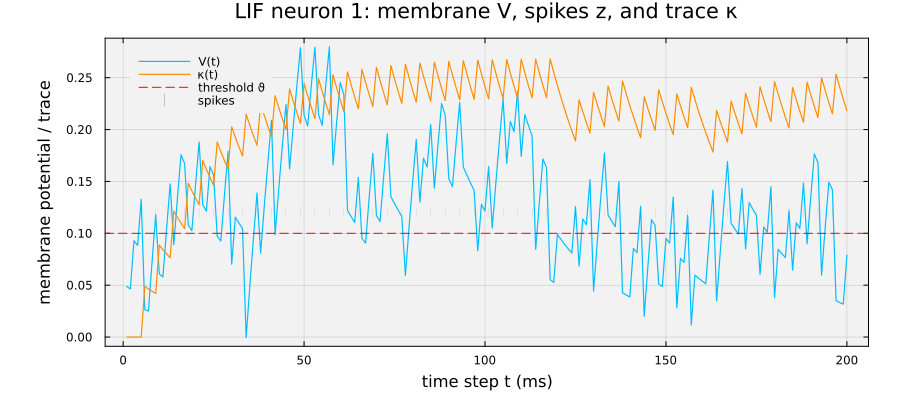

In [ ]:
let

    # initialize -
    j = 1                                          # pick neuron 1 to plot
    t_axis = 1:T_PER_PAIR # how many time steps
    spike_times = findall(==(1), S_demo[j, :])

    p = plot(t_axis, V_demo[j, :];
        label = "V(t)",
        xlabel = "time step t (ms)", ylabel = "membrane potential / trace",
        title  = "LIF neuron $(j): membrane V, spikes z, and trace κ",
        lw = 1.2, c = :deepskyblue,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p, t_axis, κ_demo[j, :]; label = "κ(t)", lw = 1.2, c = :darkorange)
    hline!(p, [ϑ]; c = :red, ls = :dash, lw = 1.0, label = "threshold ϑ")
    if !isempty(spike_times)
        scatter!(p, spike_times, fill(ϑ + 0.02, length(spike_times));
            ms = 5, msw = 0, c = :black, marker = :vline, label = "spikes")
    end

    plot(p; size = (900, 420),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What does the trace $\kappa(t)$ contribute that the raw spike train $z(t)$ does not?__ Using only the V-and-trace plot above: (a) Why does the Hebbian rule from Task 2 use $\kappa^{\text{key}}_{j}\,\kappa^{\text{value}}_{k}$ rather than $z^{\text{key}}_{j}\,z^{\text{value}}_{k}$ to update the association matrix? (b) If you doubled `τ_trace`, would the peaks of $\kappa$ become higher or lower, and would two key spikes separated by 20 ms be more or less likely to look co-active to the rule?

___

## Task 2: Spike-trace Hebbian write and recall on synthetic spike pairs
In this task, we build a spiking H-Mem network with `ELL_TASK2` LIF neurons in each of the key- and value-layers, store `N_TASK2` random (key, value) spike-train pairs in it, and verify that each stored key probes out the right value.

> __Spike-trace Hebbian write rule.__ Eq. 6 of [Limbacher, Özdenizci, and Legenstein (2022)](https://arxiv.org/abs/2205.11276) updates the association matrix at every time step as
> $$\Delta W^{\text{assoc}}_{kj}(t) = \gamma_{+}\bigl(w^{\max} - W^{\text{assoc}}_{kj}(t)\bigr)\,\kappa^{\text{value}}_{k}(t)\,\kappa^{\text{key}}_{j}(t) - \gamma_{-}\,W^{\text{assoc}}_{kj}(t)\,\bigl(\kappa^{\text{key}}_{j}(t)\bigr)^{2}.$$
> Strengthening is gated by co-activity of the key-side trace $\kappa^{\text{key}}_{j}$ and the value-side trace $\kappa^{\text{value}}_{k}$; forgetting is driven by squared key-side trace alone, which weakens connections from currently active key-coordinates so that fresh associations overwrite stale ones.

> __Recall rule.__ At recall time, the key-layer is driven by a query spike train and the value-layer is driven *only* through the association matrix as $\mathbf{I}^{\text{value}}_{t} = c\,\mathbf{W}^{\text{assoc}}\,\mathbf{z}^{\text{key}}_{t}$. The value-layer's resulting spike train is what we measure.

The code block below stores the spiking memory in `model_t2::MySpikingHMemNetwork`, the key spike trains in `keys_t2::Vector{Matrix{Int}}`, and the value spike trains in `vals_t2::Vector{Matrix{Int}}`.

In [5]:
model_t2, keys_t2, vals_t2 = let
    Random.seed!(42)
    model = build(MySpikingHMemNetwork; ell_key = ELL_TASK2, ell_value = ELL_TASK2,
        ϑ = ϑ, τ_m = τ_m, τ_trace = τ_trace, Δt = Δt, Δ_abs = Δ_abs,
        γ_plus = γ_plus, γ_minus = γ_minus, w_max = w_max)

    keys_buf = Vector{Matrix{Int}}(undef, N_TASK2)
    vals_buf = Vector{Matrix{Int}}(undef, N_TASK2)

    # Each key and value is a sparse (~20% active) Poisson spike train at MAX_RATE.
    for i in 1:N_TASK2
        k_rates = [rand() < 0.2 ? MAX_RATE : 0.0 for _ in 1:ELL_TASK2]
        v_rates = [rand() < 0.2 ? MAX_RATE : 0.0 for _ in 1:ELL_TASK2]
        keys_buf[i] = poisson_encode(k_rates, T_PER_PAIR)
        vals_buf[i] = poisson_encode(v_rates, T_PER_PAIR)
        write_phase!(model, keys_buf[i], vals_buf[i])
    end

    @info "after $(N_TASK2) writes" max_W=round(maximum(model.W_assoc); digits=3) mean_W=round(mean(model.W_assoc); digits=4) frac_W_above_0p1=round(mean(model.W_assoc .> 0.1); digits=3)
    (model, keys_buf, vals_buf)
end;

┌ Info: after 4 writes
│   max_W = 0.531
│   mean_W = 0.0625
│   frac_W_above_0p1 = 0.124
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-15/L15b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X16sZmlsZQ==.jl:19


### Recall every stored pair and a fresh untrained key
We probe the network with each stored key in turn and with one extra unseen key. The metric is the Pearson correlation between the per-neuron firing rate vector of the recalled value-layer spike train and the per-neuron firing rate vector of the *true* stored value spike train. A matched query should give correlation close to one; an unrelated query should give substantially less.

In [6]:
recall_table_t2 = let
    rows = Tuple{String, Float64, Float64}[]

    # Stored-pair recall.
    for i in 1:N_TASK2
        out      = recall_phase(model_t2, keys_t2[i]; c_assoc = c_assoc)
        recall_r = vec(mean(out.S_value; dims = 2))
        target_r = vec(mean(vals_t2[i]; dims = 2))
        ρ        = (std(recall_r) > 0 && std(target_r) > 0) ? cor(recall_r, target_r) : 0.0
        push!(rows, ("stored key $(i) → value $(i)", ρ, mean(out.S_value)))
    end

    # Fresh untrained key — should not retrieve any stored value cleanly.
    Random.seed!(99)
    fresh_rates = [rand() < 0.2 ? MAX_RATE : 0.0 for _ in 1:ELL_TASK2]
    fresh       = poisson_encode(fresh_rates, T_PER_PAIR)
    out_fresh   = recall_phase(model_t2, fresh; c_assoc = c_assoc)
    fresh_r     = vec(mean(out_fresh.S_value; dims = 2))
    target_r    = vec(mean(vals_t2[1]; dims = 2))
    ρ_fresh     = (std(fresh_r) > 0 && std(target_r) > 0) ? cor(fresh_r, target_r) : 0.0
    push!(rows, ("fresh untrained key → value 1", ρ_fresh, mean(out_fresh.S_value)))

    df = DataFrame(query = first.(rows), ρ_vs_target = getindex.(rows, 2), value_layer_rate = last.(rows))
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

 ------------------------------- ------------- ------------------
                          query   ρ_vs_target   value_layer_rate 
                         String       Float64            Float64 
 ------------------------------- ------------- ------------------
         stored key 1 → value 1        0.6821            0.08867
         stored key 2 → value 2        0.4225             0.1062
         stored key 3 → value 3        0.4031            0.09898
         stored key 4 → value 4        0.9994            0.08203
  fresh untrained key → value 1        0.3216            0.05938
 ------------------------------- ------------- ------------------


### Visualize the value-layer rasters: matched vs. fresh recall
We plot the value-layer spike rasters for two queries side by side: the stored key 1 (which should retrieve value 1) and a fresh untrained key (which should retrieve nothing in particular).

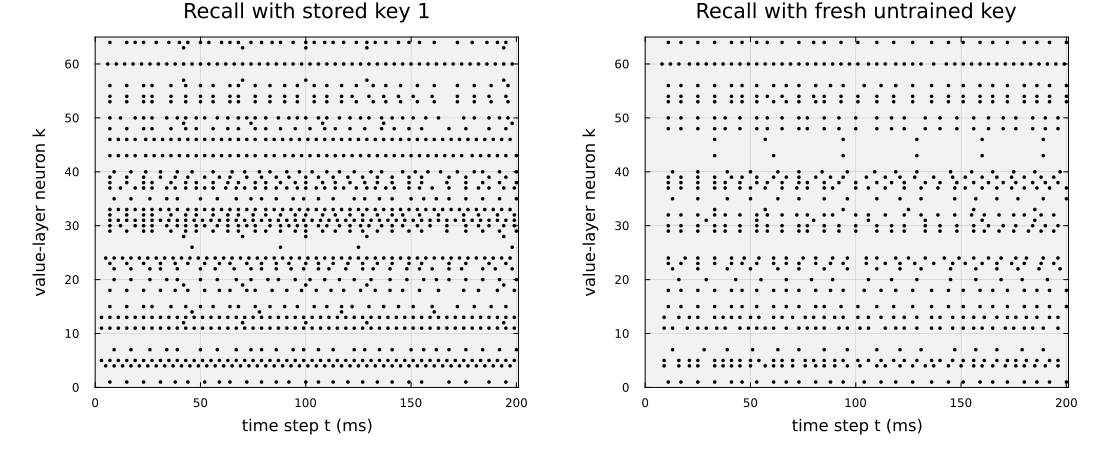

In [7]:
let
    out_match = recall_phase(model_t2, keys_t2[1]; c_assoc = c_assoc)
    Random.seed!(99)
    fresh_rates = [rand() < 0.2 ? MAX_RATE : 0.0 for _ in 1:ELL_TASK2]
    fresh       = poisson_encode(fresh_rates, T_PER_PAIR)
    out_fresh   = recall_phase(model_t2, fresh; c_assoc = c_assoc)

    function raster(S; title)
        ts = Int[]
        js = Int[]
        for t in 1:size(S, 2), j in 1:size(S, 1)
            if S[j, t] == 1
                push!(ts, t); push!(js, j)
            end
        end
        scatter(ts, js;
            ms = 2, msw = 0, c = :black, label = nothing,
            xlabel = "time step t (ms)", ylabel = "value-layer neuron k",
            title = title,
            xlims = (0, T_PER_PAIR + 1), ylims = (0, ELL_TASK2 + 1),
            bg = "gray95", background_color_outside = "white", framestyle = :box)
    end

    p1 = raster(out_match.S_value; title = "Recall with stored key 1")
    p2 = raster(out_fresh.S_value; title = "Recall with fresh untrained key")

    plot(p1, p2; layout = (1, 2), size = (1100, 460),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What does the matched-vs-fresh comparison tell you about selectivity?__ Using only the recall table and the two rasters: (a) Is the per-pair recall correlation `ρ_vs_target` substantially larger for matched queries than for the fresh query, and is the *value-layer firing rate* itself also larger for matched queries? (b) The fresh query still produces some non-zero correlation with stored value 1. Is that an artifact, or is there a real reason a random sparse key has positive expected correlation with the recalled value of any stored pair?

___

## Task 3: One-shot MNIST recall
In this task, we replace the random value-spike-trains of Task 2 with rate-coded MNIST digit images and use the spiking H-Mem to perform one-shot image recall. The setup is exactly Sec. 2.2 of [Limbacher et al. (2022)](https://arxiv.org/abs/2205.11276), reduced to its memory-module essence: there is no training, no encoder; we just stream (key, image) pairs through the Hebbian write rule and probe with each key.

> __Network shape and encoding.__
>
> The key-layer has `ELL_KEY = 64` LIF neurons; the value-layer has `ELL_VALUE = MNIST_ROWS * MNIST_COLS = 784` LIF neurons, one per pixel. Each (key, value) pair is presented for `T_PER_PAIR = 200` ms. The key input is a sparse Poisson spike train across the 64 key-neurons; the value input is a Poisson rate-coded MNIST image (per-pixel firing probability $p_{j} = $ `MAX_RATE` $\cdot\,\mathrm{pixel}_{j}$). After all pairs have been written, recall is run by feeding the same key into the network alone and decoding the value-layer's spike matrix back into an image as the per-neuron mean firing rate, reshaped to $28\times 28$.

The code block below stores the spiking memory in `model_t3`, the key spike trains in `keys_t3`, the original images in `imgs_t3`, and the recalled images in `recall_imgs::Vector{Matrix{Float64}}`.

In [8]:
model_t3, keys_t3, imgs_t3, recall_imgs = let
    Random.seed!(42)
    model = build(MySpikingHMemNetwork; ell_key = ELL_KEY, ell_value = ELL_VALUE,
        ϑ = ϑ, τ_m = τ_m, τ_trace = τ_trace, Δt = Δt, Δ_abs = Δ_abs,
        γ_plus = γ_plus, γ_minus = γ_minus, w_max = w_max)

    N = length(DIGITS_TO_STORE)
    keys_buf  = Vector{Matrix{Int}}(undef, N)
    imgs_buf  = Vector{Matrix{Float64}}(undef, N)

    # Step 1: write every (random key, MNIST digit image) pair into the memory.
    for i in 1:N
        # Random sparse key (~20% active key-neurons firing at MAX_RATE).
        k_rates = [rand() < 0.2 ? MAX_RATE : 0.0 for _ in 1:ELL_KEY]
        K = poisson_encode(k_rates, T_PER_PAIR)

        # MNIST digit value, encoded as one Poisson spike train per pixel.
        img = load_mnist_image(DIGITS_TO_STORE[i], 1)
        V_in = image_to_rate_input(img, T_PER_PAIR; max_rate = MAX_RATE)

        keys_buf[i] = K
        imgs_buf[i] = img
        write_phase!(model, K, V_in)
    end

    # Step 2: recall each digit by re-presenting its key alone.
    recalls = Vector{Matrix{Float64}}(undef, N)
    for i in 1:N
        out         = recall_phase(model, keys_buf[i]; c_assoc = c_assoc)
        recalls[i]  = decode_value_spikes(out.S_value, MNIST_ROWS, MNIST_COLS)
    end

    @info "after $(N) MNIST writes" max_W=round(maximum(model.W_assoc); digits=3) mean_W=round(mean(model.W_assoc); digits=4) ELL_KEY=ELL_KEY ELL_VALUE=ELL_VALUE T_PER_PAIR=T_PER_PAIR
    (model, keys_buf, imgs_buf, recalls)
end;

┌ Info: after 3 MNIST writes
│   max_W = 0.559
│   mean_W = 0.0338
│   ELL_KEY = 64
│   ELL_VALUE = 784
│   T_PER_PAIR = 200
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-15/L15b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:33


### Visualize: original image vs. recalled image
We arrange originals on the top row and the corresponding recalled images on the bottom row. The recalled images are per-neuron firing rates of the value-layer over the recall window, reshaped to $28\times 28$. They are rescaled to the same dynamic range as the originals so structure is comparable by eye.

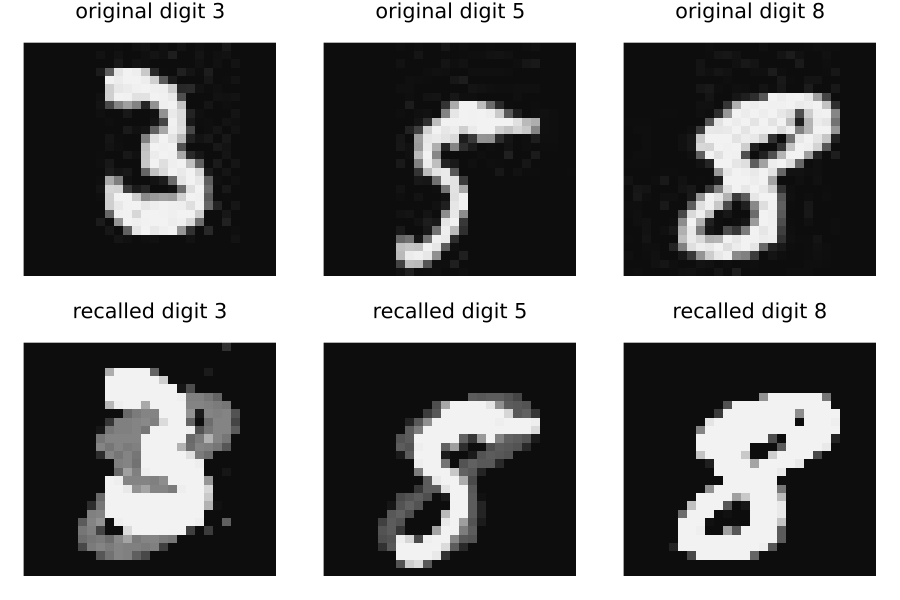

In [9]:
let
    N = length(DIGITS_TO_STORE)
    panels = Plots.Plot[]
    for i in 1:N
        push!(panels, heatmap(imgs_t3[i];
            yflip = true, c = :grays, clims = (0.0, 1.0),
            colorbar = false, axis = false, ticks = false,
            title = "original digit $(DIGITS_TO_STORE[i])"))
    end
    for i in 1:N
        rec = recall_imgs[i]
        rec_norm = maximum(rec) > 0 ? rec ./ maximum(rec) : rec  # rescale to [0, 1] for display
        push!(panels, heatmap(rec_norm;
            yflip = true, c = :grays, clims = (0.0, 1.0),
            colorbar = false, axis = false, ticks = false,
            title = "recalled digit $(DIGITS_TO_STORE[i])"))
    end

    plot(panels...; layout = (2, N), size = (300 * N, 600),
        left_margin = 4Plots.mm, bottom_margin = 4Plots.mm,
        right_margin = 4Plots.mm, top_margin = 4Plots.mm)
end

### Recall correlation table: matched vs. cross-recall
We probe the network with each stored key and compare the recalled image against *every* stored original. The matched (key i → image i) entries should be high; the cross (key i → image j, j≠i) entries should be much lower. This is the spiking analogue of the load-factor sweep we ran in the L15a example.

In [10]:
cross_recall_table = let
    N = length(DIGITS_TO_STORE)
    M = zeros(Float64, N, N)
    for q in 1:N, t in 1:N
        rec = recall_imgs[q]
        tgt = imgs_t3[t]
        if std(rec) > 0 && std(tgt) > 0
            M[q, t] = cor(vec(rec), vec(tgt))
        end
    end

    df = DataFrame()
    df[!, "query\\target"] = ["key $(DIGITS_TO_STORE[q])" for q in 1:N]
    for t in 1:N
        df[!, "img $(DIGITS_TO_STORE[t])"] = [round(M[q, t]; digits = 3) for q in 1:N]
    end

    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    df
end;

 --------------- --------- --------- ---------
  query\\target     img 3     img 5     img 8 
         String   Float64   Float64   Float64 
 --------------- --------- --------- ---------
          key 3     0.867     0.392      0.59
          key 5     0.192     0.926     0.831
          key 8     0.251     0.591     0.964
 --------------- --------- --------- ---------


### Things to think about
* __What does the cross-recall table tell you about selectivity in the spiking case?__ Using only the original-vs-recalled grid and the cross-recall table: (a) Is the diagonal of the table substantially larger than the off-diagonal entries, and roughly by how much? (b) The recalled images look slightly washed-out compared to the originals. Where in the pipeline does that loss of contrast happen — in the Hebbian write, in the LIF integration during recall, or in the per-neuron-rate decoding step that turns spikes back into pixels?
* __What would change if you increased $N$ from 3 to 10?__ The L15a example showed the recall correlation degrades smoothly past load factor $K/m \approx 1$. Here the value-layer has $\ell^{\text{value}} = 784$ neurons and the key-layer $\ell^{\text{key}} = 64$, so the relevant capacity-limiting dimension is $\ell^{\text{key}}$. At what $N$ would you expect the matched-recall correlation to start visibly degrading, and what would the recalled images look like in that regime?

___

## Summary
This lab implemented the spiking Hebbian Memory Network of [Limbacher, Özdenizci, and Legenstein (2022)](https://arxiv.org/abs/2205.11276) in miniature. We started from a single LIF layer and its synaptic trace $\kappa(t)$, lifted the rate-domain Hebbian rule of the L15a example onto the spike-trace pair $(\kappa^{\text{key}}, \kappa^{\text{value}})$, and applied the resulting spiking H-Mem to one-shot recall of MNIST digit images. The encoders were untrained throughout — every association was written into the network by the local Hebbian rule alone.

> __Key Takeaways:__
>
> * **Spike traces give the Hebbian rule a working time window:** The low-pass filter $\kappa(t)$ with time constant $\tau_{\text{trace}} \approx 20$ ms turns instantaneous binary spikes into continuous co-activity scores, so the outer-product $\kappa^{\text{value}}_{k}\,\kappa^{\text{key}}_{j}$ counts pre- and post-synaptic spikes that fall within roughly one trace time constant of each other rather than only the ones that happen on the exact same time step.
> * **The rate-domain capacity story carries over to the spiking case:** Recall correlation is high when the query matches a stored key, falls when the query is unrelated, and the value-layer's overall firing rate also goes down for unrelated queries. The capacity is set by the key-layer dimension $\ell^{\text{key}}$, exactly as in the L15a example.
> * **One-shot MNIST recall works without training any encoder:** Storing $N = 3$ (random key, MNIST digit) pairs takes $N\cdot T_{\text{per pair}}$ ms of simulation and zero gradient steps; the recalled images closely resemble the originals along the diagonal of the recall table and are uncorrelated off-diagonal. This is the regime in which neuromorphic chips are interesting at deployment: the heavy lifting is the local Hebbian update, not a backprop pass.

Two natural extensions, both inside the framework we built:
* Sweep $N$ to recover the capacity knee from the L15a example, but now in the spiking domain.
* Train the input encoders by BPTT with surrogate gradients, as the 2022 paper does, to convert the random-projection key encoder we used here into a learned encoder that produces well-separated keys.
___